# Vehicle Collision Prediction Using Machine Learning

This notebook combines the data processing and analysis into the machine learning pipeline to ensure clean and accurate data transformations

### Global Imports
Import required libraries for the remainder of the notebook

In [16]:
# import os to set root folder
import os
os.chdir('c:/Users/01eco/Documents/Programming/Python/multisource_ML_research')
# import pandas for data storage & manipulation
import pandas as pd
# import seaborn and pyplot for figure generation
import seaborn as sns
import matplotlib.pyplot as plt
# import numpy for data processing
import numpy as np
# import tqdm for visual loop tracking
from tqdm import tqdm
# set warning filters to ignore mixed type warnings and performance warnings that are corrected in processing
import warnings
from pandas.errors import DtypeWarning
warnings.filterwarnings("ignore", category=DtypeWarning)
warnings.filterwarnings(action="ignore", category=pd.errors.PerformanceWarning)

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import time

random_state = 42

## Raw Data Collection and Preprocessing

### Variable Definitions
Define variables to use in the Raw Data Collection and Preprocessing stages

In [2]:
# import_from_raw is used to set whether to read from the raw data folder or the processed data folder
import_from_raw = False

# set parameters for processing
encounter_length_back = 10 #backward time offset from point of driver closest to intersection
encounter_length_forward = 2 #forward time offset from point of driver closest to intersection
polynomial_interpolation_order = 1 # polynomial order used for interpolation
collision_radius = 3 # distance threshold for marking collisions

collision_counts = 0 # tally for the number of collisions
total_encounters = 0 # tally for the total number of encounters
encounter_list = []

encounter_meta = pd.DataFrame()

time_threshold = 0.1 # seconds (100ms) for what is considered to be a fixation
dispersion_threshold = 0.03 # dispersion threshold in normalized units (for the Tobii Eye Tracker glasses)

# column list for interpolation and hazard selection
interpolate_column_list = [
    'CoG Acceleration/X','CoG Acceleration/Y','CoG position/X','CoG position/Y',
    'Speed/X','Speed/Y','Brake pedal force','Gas pedal','Steering wheel angle','Steering wheel speed',
    'CoG Acceleration/X.1','CoG Acceleration/Y.1','CoG position/X.1','CoG position/Y.1','Pitch acceleration.1','Pitch speed.1','Roll acceleration.1','Roll speed.1','Speed/X.1','Speed/Y.1','Tangential speed.1','Yaw acceleration.1','Yaw speed.1',
    'CoG Acceleration/X.2','CoG Acceleration/Y.2','CoG position/X.2','CoG position/Y.2','Pitch acceleration.2','Pitch speed.2','Roll acceleration.2','Roll speed.2','Speed/X.2','Speed/Y.2','Tangential speed.2','Yaw acceleration.2','Yaw speed.2',
    'CoG Acceleration/X.3','CoG Acceleration/Y.3','CoG position/X.3','CoG position/Y.3','Pitch acceleration.3','Pitch speed.3','Roll acceleration.3','Roll speed.3','Speed/X.3','Speed/Y.3','Tangential speed.3','Yaw acceleration.3','Yaw speed.3',
    'CoG Acceleration/X.4','CoG Acceleration/Y.4','CoG position/X.4','CoG position/Y.4','Pitch acceleration.4','Pitch speed.4','Roll acceleration.4','Roll speed.4','Speed/X.4','Speed/Y.4','Tangential speed.4','Yaw acceleration.4','Yaw speed.4',
    'Data Gaze2D X','Data Gaze2D Y',
    'Data Gaze3D X','Data Gaze3D Y','Data Gaze3D Z',
    'Data Eyeleft Gazeorigin X','Data Eyeleft Gazeorigin Y','Data Eyeleft Gazeorigin Z',
    'Data Eyeleft Gazedirection X','Data Eyeleft Gazedirection Y','Data Eyeleft Gazedirection Z',
    'Data Eyeleft Pupildiameter',
    'Data Eyeright Gazeorigin X','Data Eyeright Gazeorigin Y','Data Eyeright Gazeorigin Z',
    'Data Eyeright Gazedirection X','Data Eyeright Gazedirection Y','Data Eyeright Gazedirection Z',
    'Data Eyeright Pupildiameter',
    'Data Accelerometer X','Data Accelerometer Y','Data Accelerometer Z',
    'Data Gyroscope X','Data Gyroscope Y','Data Gyroscope Z',
    'Data Magnetometer X','Data Magnetometer Y','Data Magnetometer Z'
]

eyetracking_column_list = [
    'Data Eyeleft Gazeorigin X','Data Eyeleft Gazeorigin Y','Data Eyeleft Gazeorigin Z',
    'Data Eyeleft Gazedirection X','Data Eyeleft Gazedirection Y','Data Eyeleft Gazedirection Z',
    'Data Eyeleft Pupildiameter',
    'Data Eyeright Gazeorigin X','Data Eyeright Gazeorigin Y','Data Eyeright Gazeorigin Z',
    'Data Eyeright Gazedirection X','Data Eyeright Gazedirection Y','Data Eyeright Gazedirection Z',
    'Data Eyeright Pupildiameter'
]

# set up columns for initial drop
drop_column_list = [
    'Type_x','Type_y',
    'Intersection Id',
    'ExportChannel/1','ExportChannel/4','ExportChannel/3',
    'CoG position/Roll','CoG position/Pitch','CoG position/Yaw',
    'Tangent Acceleration/X','Tangent Acceleration/Y','Tangential speed','Yaw %ground','Yaw acceleration','Yaw speed',
    'Horizontal tangential speed','Over-steering criteria2','Pitch %ground','Pitch acceleration','Pitch speed','Roll %ground','Roll acceleration','Roll speed','Slope force',
    'Lane gap'
]

In [3]:
# the following will import and process data from raw data. it will also save data to the file system for later
if import_from_raw:
    #* read the participant data summary file to get list of participants
    participant_data_summary = pd.read_excel('summary_files/data_summary.xlsx')

    # iterate through all participants in participant summary list
    for participant_summary_row_tuple in tqdm(participant_data_summary.itertuples(),desc='Participants',total=len(participant_data_summary),colour='green'):
        participant_summary_row = participant_summary_row_tuple._asdict()
        participant_id = participant_summary_row['participant_id'] # get participant id 
        route_id = participant_summary_row['HazardOrder'] # get hazard order of participant drive (0-3)
        timestamp_offset = participant_summary_row['TimeDifferenceEtoD'] # get time offset between the eye tracking and driving (eyetracking - driving = offset)

        # get additional metadata about the participant
        participant_gender = participant_summary_row['Gender']
        participant_age = participant_summary_row['CurrentAge']
        participant_licence_type = participant_summary_row['Licence']
        participant_driving_type = participant_summary_row['Type']
        participant_driving_experience = participant_summary_row['DrivingExperience']
        participant_avg_km = participant_summary_row['AvgKM']
        participant_driving_frequency = participant_summary_row['MonthlyDrivingFrequency']

        #* read in the participant driving data - mixed datatype warnings are ignored
        # separate by either comma or semicolon to avoid inconsistencies in the dataset
        # use encoding to read the data properly
        # set range of columns to read to be 0-86 since some of the files have extra deliminator at the end of the header row
        participant_driving_data = pd.read_csv(f'data/raw_data/participant_{participant_id}/driving_{participant_id}.csv', sep='[,;]', header=0, encoding='ISO-8859-1', engine='python', usecols=range(0,86))
        participant_driving_data.drop(index=0, inplace=True) # drop units row
        participant_driving_data = participant_driving_data.apply(pd.to_numeric) # update dtypes to be numeric data
        # print(participant_driving_data.isna().sum().sum()) # check for null values in the dataset
        participant_driving_data.rename(columns={'ï»¿Time':'Timestamp','Time':'Timestamp'},inplace=True) # fix name of time column

        # participant_driving_data_description = participant_driving_data.describe() # get statistics of driving data to make sure everything is in an expected range
        # print(f'participant {participant_id} driving data stats = {participant_driving_data_description['Timestamp']}')

        #* read in the gaze data from the eye tracking dataset
        participant_gaze_data = pd.read_excel(f'data/raw_data/participant_{participant_id}/eye_tracking_{participant_id}.xlsx',sheet_name='Gaze Data')
        # print(f'participant {participant_id} gaze data stats = {participant_gaze_data.describe()['Timestamp']}')

        #* read in the eye tracking IMU data
        participant_imu_data = pd.read_excel(f'data/raw_data/participant_{participant_id}/eye_tracking_{participant_id}.xlsx',sheet_name='IMU Data')
        # print(f'participant {participant_id} imu data stats = {participant_imu_data.describe()['Timestamp']}')

        #! Adjust timestamps before merging data together (eyetracking = driving + offset)
        participant_gaze_data['Timestamp'] = participant_gaze_data['Timestamp'] + timestamp_offset
        participant_imu_data['Timestamp'] = participant_imu_data['Timestamp'] + timestamp_offset
        
        #! Merge the three sets of data into a new dataframe
        merged_participant_data = participant_driving_data.merge(participant_gaze_data,on='Timestamp',how='outer').merge(participant_imu_data,on='Timestamp',how='outer')
        merged_participant_data.drop(drop_column_list,axis=1,inplace=True) # remove some unneeded columns from the dataset

        # Apply Interpolation to the Dataset
        merged_participant_data.sort_values('Timestamp',inplace=True) # sort to enforce time series as an increasing value
        merged_participant_data.set_index('Timestamp',inplace=True) # use the timestamp as an index temporarily

        merged_participant_data[interpolate_column_list] = merged_participant_data[interpolate_column_list].interpolate(method='polynomial',order=polynomial_interpolation_order) # perform interpolation on the dataset
        merged_participant_data[interpolate_column_list] = merged_participant_data[interpolate_column_list].ffill().bfill()
        merged_participant_data.reset_index(inplace=True) # reset the index of the dataframe

        # calculate averages of the eye tracking data
        merged_participant_data['Avg_Gazeorigin_X'] = (merged_participant_data['Data Eyeleft Gazeorigin X'] + merged_participant_data['Data Eyeright Gazeorigin X'])/2
        merged_participant_data['Avg_Gazeorigin_Y'] = (merged_participant_data['Data Eyeleft Gazeorigin Y'] + merged_participant_data['Data Eyeright Gazeorigin Y'])/2
        merged_participant_data['Avg_Gazeorigin_Z'] = (merged_participant_data['Data Eyeleft Gazeorigin Z'] + merged_participant_data['Data Eyeright Gazeorigin Z'])/2

        merged_participant_data['Avg_Gazedirection_X'] = (merged_participant_data['Data Eyeleft Gazedirection X'] + merged_participant_data['Data Eyeright Gazedirection X'])/2
        merged_participant_data['Avg_Gazedirection_Y'] = (merged_participant_data['Data Eyeleft Gazedirection Y'] + merged_participant_data['Data Eyeright Gazedirection Y'])/2
        merged_participant_data['Avg_Gazedirection_Z'] = (merged_participant_data['Data Eyeleft Gazedirection Z'] + merged_participant_data['Data Eyeright Gazedirection Z'])/2
        
        merged_participant_data['Avg_Pupildiameter'] = (merged_participant_data['Data Eyeleft Pupildiameter'] + merged_participant_data['Data Eyeright Pupildiameter'])/2
        merged_participant_data.drop(eyetracking_column_list,axis=1,inplace=True)

        #! dispersion threshold technique to determine fixations/saccades in the dataset
        # apply to entire set of data first before removing encounters
        #? https://dl.acm.org/doi/pdf/10.1145/355017.355028#:~:text=I%2DVT%20then%20classifies%20each,groups%20and%20discards%20saccade%20points. 
        
        current_fixation_id = 0
        window_start = 0 #set starting index for the current fixation window

        merged_participant_data['fixation_id'] = -1 # default to -1
        merged_participant_data['event_type'] = 1 # default to saccade (1)
        merged_participant_data['fixation_start_time'] = np.nan
        merged_participant_data['fixation_end_time'] = np.nan
        merged_participant_data['fixation_duration'] = np.nan
        merged_participant_data['fixation_centroid_x'] = np.nan
        merged_participant_data['fixation_centroid_y'] = np.nan
        merged_participant_data['fixation_point_count'] = np.nan
        merged_participant_data['fixation_dispersion_x'] = np.nan
        merged_participant_data['fixation_dispersion_y'] = np.nan
        merged_participant_data['fixation_dispersion'] = np.nan

        while window_start < len(merged_participant_data) - 1:
            window_end = window_start + 1 # set window end to the next index for the current fixation window
            fixation_found = False # flag to determine if fixation is found or not

            # expand the current fixation window while the dispersion is still within the threshold
            while window_end < len(merged_participant_data):
                # get the current fixation window x,y coordinates
                window_points_x = merged_participant_data['Data Gaze2D X'].iloc[window_start:window_end+1].values
                window_points_y = merged_participant_data['Data Gaze2D Y'].iloc[window_start:window_end+1].values

                # calculate dispersion: (max_x - min_x) + (max_y - min_y) for the current window
                dispersion = (np.max(window_points_x) - np.min(window_points_x)) + (np.max(window_points_y) - np.min(window_points_y))

                # if the dispersion is greater than the threshold, that is the end of the current window
                if dispersion > dispersion_threshold:
                    # exceeds dispersion threshold
                    break
                
                # calculate current fixation window duration
                window_duration = merged_participant_data['Timestamp'].iloc[window_end] - merged_participant_data['Timestamp'].iloc[window_start]

                # if the dispersion is less than the threshold, check the duration. if the duration is greater than the time, calculate the fixation metrics to store
                if window_duration >= time_threshold:
                    # assign fixation event and fixation id
                    merged_participant_data.loc[window_start:window_end,'fixation_id'] = current_fixation_id
                    merged_participant_data.loc[window_start:window_end,'event_type'] = 0 # fixation (0)

                    fixation_start_time = merged_participant_data['Timestamp'].iloc[window_start]
                    fixation_end_time = merged_participant_data['Timestamp'].iloc[window_end]
                    fixation_duration = fixation_end_time - fixation_start_time
                    fixation_centroid_x = np.mean(window_points_x)
                    fixation_centroid_y = np.mean(window_points_y)
                    fixation_point_count = window_end - window_start + 1

                    fixation_dispersion_x = np.max(window_points_x) - np.min(window_points_x)
                    fixation_dispersion_y = np.max(window_points_y) - np.min(window_points_y)

                    merged_participant_data.loc[window_start:window_end,'fixation_start_time'] = fixation_start_time
                    merged_participant_data.loc[window_start:window_end,'fixation_end_time'] = fixation_end_time
                    merged_participant_data.loc[window_start:window_end,'fixation_duration'] = fixation_duration
                    merged_participant_data.loc[window_start:window_end,'fixation_centroid_x'] = fixation_centroid_x
                    merged_participant_data.loc[window_start:window_end,'fixation_centroid_y'] = fixation_centroid_y
                    merged_participant_data.loc[window_start:window_end,'fixation_point_count'] = fixation_point_count
                    merged_participant_data.loc[window_start:window_end,'fixation_dispersion_x'] = fixation_dispersion_x
                    merged_participant_data.loc[window_start:window_end,'fixation_dispersion_y'] = fixation_dispersion_y
                    merged_participant_data.loc[window_start:window_end,'fixation_dispersion'] = dispersion

                    # move on to next fixation
                    current_fixation_id += 1
                    # set new starting window
                    window_start = window_end + 1
                    fixation_found = True
                    break

                window_end += 1
            
            if not fixation_found:
                fixation_dispersion_x = np.max(window_points_x) - np.min(window_points_x)
                fixation_dispersion_y = np.max(window_points_y) - np.min(window_points_y)

                merged_participant_data.loc[window_start:window_end,'fixation_id'] = -1 # no fixation
                merged_participant_data.loc[window_start:window_end,'event_type'] = 1 # fixation (0)
                merged_participant_data.loc[window_start,'fixation_start_time'] = merged_participant_data['Timestamp'].loc[window_start]
                merged_participant_data.loc[window_start,'fixation_end_time'] = merged_participant_data['Timestamp'].loc[window_start]
                merged_participant_data.loc[window_start,'fixation_duration'] = 0
                merged_participant_data.loc[window_start,'fixation_centroid_x'] = merged_participant_data['Data Gaze2D X'].iloc[window_start]
                merged_participant_data.loc[window_start,'fixation_centroid_y'] = merged_participant_data['Data Gaze2D X'].iloc[window_start]
                merged_participant_data.loc[window_start,'fixation_point_count'] = 0
                merged_participant_data.loc[window_start,'fixation_dispersion_x'] = fixation_dispersion_x
                merged_participant_data.loc[window_start,'fixation_dispersion_y'] = fixation_dispersion_y
                merged_participant_data.loc[window_start,'fixation_dispersion'] = dispersion

                window_start += 1

        # !after merge of data and interpolation, use timestamps of just the data in the participant_gaze_data and remove rows of the rest
        # ?this will effectively set the lowest frequency clock (gaze data) as the main clock and downsample the faster clocks (driving and IMU)
        merged_participant_data = merged_participant_data[merged_participant_data['Timestamp'].isin(participant_gaze_data['Timestamp'])]

        #* read the intersection data for the route driven by the participant
        intersection_location_sheetname = f'route_{route_id}'
        intersection_location_data = pd.read_excel('summary_files/intersection_locations.xlsx', sheet_name=intersection_location_sheetname)
        # route_direction_summary = pd.read_excel('summary_files/intersection_locations.xlsx',sheet_name='route_summary')
        # route_direction = route_direction_summary[route_direction_summary['route'] == route_id]['direction'].iloc[0] # if the route is forward, leave as is. if route is reverse, update data accordingly
        
        # iterate through each of the hazards in the order in which they appear in the given route
        for intersection_id in range(0,4):
            # obtain the intersection type
            intersection_type = intersection_location_data[intersection_location_data['intersection_id'] == intersection_id]['intersection_type'].iloc[0]
            # obtain the intersection location for the current route as a tuple representing (x,y) coordinates
            intersection_location = tuple(intersection_location_data[intersection_location_data['intersection_id'] == intersection_id][['x', 'y']].iloc[0])
            intersection_hazard_id = intersection_location_data[intersection_location_data['intersection_id'] == intersection_id]['hazard_id'].iloc[0]

            # specify hazard columns to aid in removal of non-hazard columns
            hazard_data_columns = [
                ['CoG Acceleration/X.1','CoG Acceleration/Y.1','CoG position/X.1','CoG position/Y.1','Pitch acceleration.1','Pitch speed.1','Roll acceleration.1','Roll speed.1','Speed/X.1','Speed/Y.1','Tangential speed.1','Yaw acceleration.1','Yaw speed.1'],
                ['CoG Acceleration/X.2','CoG Acceleration/Y.2','CoG position/X.2','CoG position/Y.2','Pitch acceleration.2','Pitch speed.2','Roll acceleration.2','Roll speed.2','Speed/X.2','Speed/Y.2','Tangential speed.2','Yaw acceleration.2','Yaw speed.2'],
                ['CoG Acceleration/X.3','CoG Acceleration/Y.3','CoG position/X.3','CoG position/Y.3','Pitch acceleration.3','Pitch speed.3','Roll acceleration.3','Roll speed.3','Speed/X.3','Speed/Y.3','Tangential speed.3','Yaw acceleration.3','Yaw speed.3'],
                ['CoG Acceleration/X.4','CoG Acceleration/Y.4','CoG position/X.4','CoG position/Y.4','Pitch acceleration.4','Pitch speed.4','Roll acceleration.4','Roll speed.4','Speed/X.4','Speed/Y.4','Tangential speed.4','Yaw acceleration.4','Yaw speed.4']
            ]

            # new column name to replace the remaining column
            hazard_data_column_update = [
                'CoG Acceleration/X.haz','CoG Acceleration/Y.haz','CoG position/X.haz','CoG position/Y.haz','Pitch acceleration.haz','Pitch speed.haz','Roll acceleration.haz','Roll speed.haz','Speed/X.haz','Speed/Y.haz','Tangential speed.haz','Yaw acceleration.haz','Yaw speed.haz'
            ]

            # current column names
            hazard_of_interest = hazard_data_columns.pop(intersection_hazard_id) # remove current hazard column names from column name list so that the rest can be used to remove from data
            hazard_data_columns = [column_name for hazard_column_sublist in hazard_data_columns for column_name in hazard_column_sublist] # flatten column name list of columns to drop from dataframe

            total_hazard_displacement = np.sqrt((merged_participant_data[f'CoG position/X.{intersection_hazard_id+1}'].iloc[-1] - merged_participant_data[f'CoG position/X.{intersection_hazard_id+1}'].iloc[0])**2 + (merged_participant_data[f'CoG position/Y.{intersection_hazard_id+1}'].iloc[-1] - merged_participant_data[f'CoG position/Y.{intersection_hazard_id+1}'].iloc[0])**2)
            total_hazard_unique_pos = merged_participant_data[f'CoG position/X.{intersection_hazard_id+1}'].nunique()
            
            # calculate the distance of the ego to the current intersection for all records in the driving data
            dist_to_intersection = np.sqrt((merged_participant_data['CoG position/X'] - intersection_location[0])**2+(merged_participant_data['CoG position/Y'] - intersection_location[1])**2)
            minimum_distance = dist_to_intersection.min() # minimum distance found between the ego and the intersection location

            # calculate mid time bound of the driving data and eye tracking data from the merged data (midtime is used to allow offset before and after point of intersection)
            encounter_mid_time = merged_participant_data.loc[dist_to_intersection.idxmin(), 'Timestamp'] # use the minimum distance to obtain the time of closest approach from the driving data

            # calculate start time bound of the driving data and eye tracking data from the merged data
            encounter_start_time = encounter_mid_time - encounter_length_back# (midtime - starttime = encounter_length backward) => (starttime = endtime - encounter_length)
            encounter_end_time = encounter_mid_time + encounter_length_forward # (endtime - midtime = encounter length forward)

            # * perform slicing to extract encounter from full drive
            # some of the driving data has a drop in frequency part way through which results in a small percentage (<1%) of the encounters being slightly more sparse than others
            # also drop non hazard columns
            encounter_slice = merged_participant_data[(encounter_start_time <= merged_participant_data['Timestamp']) & (merged_participant_data['Timestamp'] <= encounter_end_time)].drop(hazard_data_columns,axis=1)
            encounter_slice.reset_index(drop=True,inplace=True) # reset the index after pulling slice from main data
            
            # update hazard data names to be generic
            hazard_rename_map = dict(zip(hazard_of_interest,hazard_data_column_update))
            encounter_slice.rename(columns=hazard_rename_map,inplace=True)
            # drop unused hazard data
            encounter_slice.drop(['CoG Acceleration/X.haz','CoG Acceleration/Y.haz','Pitch acceleration.haz','Pitch speed.haz','Roll acceleration.haz','Roll speed.haz','Speed/X.haz','Speed/Y.haz','Tangential speed.haz','Yaw acceleration.haz','Yaw speed.haz'],axis=1,inplace=True)

            # calculate distance between ego and hazard and obtain the minimum distance from that set
            encounter_slice['ego_to_haz_dist'] = np.sqrt((encounter_slice['CoG position/X']-encounter_slice['CoG position/X.haz'])**2 + (encounter_slice['CoG position/Y']-encounter_slice['CoG position/Y.haz'])**2)
            min_dist_to_haz = min(encounter_slice['ego_to_haz_dist']) # get the minimum distance between the hazard and the ego vehicle
            time_of_min_dist = encounter_slice[encounter_slice['ego_to_haz_dist'] == min_dist_to_haz]['Timestamp'].iloc[0] # get the time of minimum distance between the hazard and ego vehcile

            # check the distance betweent he ego and hazard to determine if it is within the radius
            # also calculate time to collision using time of minimum distance as the midpoint
            # non collision ttc is set to 999
            collision_flag = (min_dist_to_haz <= collision_radius) # determine if there is collision

            if collision_flag:
                collision_counts += 1
                encounter_slice['time_to_collision'] = time_of_min_dist - encounter_slice['Timestamp'] # use time of minimum distance to hazard as the midpoitn to calculate time to collision
            else:
                encounter_slice['time_to_collision'] = 999 # set time to collision for non collisions to high value

            # collect encounter slice along with its metadata for analysis
            encounter = {
                'encounter_meta':{
                    'participant_id':participant_id,
                    'participant_gender':participant_gender,
                    'participant_age':participant_age,
                    'participant_licence_type':participant_licence_type,
                    'participant_driving_type':participant_driving_type,
                    'participant_driving_experience':participant_driving_experience,
                    'participant_avg_km':participant_avg_km,
                    'participant_driving_frequency':participant_driving_frequency,
                    'route_id':route_id,
                    'intersection_id':intersection_id,
                    'intersection_type':intersection_type,
                    'collision_flag':collision_flag,
                    'min_dist_to_haz':min_dist_to_haz,
                    'time_of_min_dist':time_of_min_dist,
                    'total_hazard_displacement':total_hazard_displacement,
                    'total_hazard_unique_pos':total_hazard_unique_pos,
                    'encounter_id':total_encounters,
                    'encounter_size':len(encounter_slice),
                    'encounter_path':f'data/intermediary_data/clean_encounters/encounter_{total_encounters}.csv'
                },
                'encounter_data':encounter_slice,
            }

            # save the encounter data to a csv as a backup
            os.makedirs(f'data/intermediary_data/clean_encounters', exist_ok=True)
            encounter_slice.to_csv(f'data/intermediary_data/clean_encounters/encounter_{total_encounters}.csv')

            encounter_meta = pd.concat([encounter_meta,pd.DataFrame([encounter['encounter_meta']])],ignore_index=True) # save just the metadata to a summary file
            encounter_meta.to_csv(f'data/intermediary_data/clean_encounters/encounter_meta.csv',index=False) # update the metadata right away after adding to dataframe..will create slight cpu overhead but will keep track of all saved data as it progresses

            # also add the encounter to a list for use later in the code
            encounter_list.append(encounter)
            total_encounters += 1 # increase tally of encounters
else:
    # read data into encounter_list directly from the folder itself
    encounter_meta = pd.read_csv(f'data/intermediary_data/clean_encounters/encounter_meta.csv')

    # iterate through the rows of the metadata
    for single_encounter_meta_tuple in tqdm(encounter_meta.itertuples(),desc='Encounters',total=len(encounter_meta),colour='green'):
        single_encounter_meta = single_encounter_meta_tuple._asdict() # convert row to dict (meta data for the given encounter)
        encounter_data = pd.read_csv(single_encounter_meta['encounter_path']) # get the data using the path in the meta
        # combine the encounter meta with the encounter data
        encounter = {
            'encounter_meta' : single_encounter_meta,
            'encounter_data': encounter_data
        }
        # append encounter to list to match the raw data implementation
        encounter_list.append(encounter)


Encounters: 100%|██████████| 280/280 [00:03<00:00, 72.17it/s]


### Metadata Analysis
Seaborn charts plotting the encounter metadata and statistics

In [4]:
encounter_meta.describe()

,participant_id,participant_age,participant_driving_experience,participant_avg_km,route_id,intersection_id,min_dist_to_haz,time_of_min_dist,total_hazard_displacement,total_hazard_unique_pos,encounter_id,encounter_size
count,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000
mean,34.500000,25.528571,9.271429,24.142857,1.485714,1.500000,131.290784,289.831168,618.415950,5665.853571,139.500000,593.082143
std,20.241375,11.559069,11.401970,27.472390,1.107069,1.120036,263.037883,145.665541,818.558862,6576.027291,80.973247,12.019266
min,0.000000,17.000000,0.000000,3.000000,0.000000,0.000000,0.029254,46.549497,0.000000,3.000000,0.000000,500.000000
25%,17.000000,19.000000,3.000000,10.000000,1.000000,0.750000,4.600371,178.159140,43.602491,1131.000000,69.750000,593.000000
50%,34.500000,21.000000,5.000000,15.000000,1.000000,1.500000,11.441404,282.908576,200.774505,2742.500000,139.500000,599.000000
75%,52.000000,25.000000,9.000000,22.000000,2.000000,2.250000,38.951908,410.040127,1007.892380,7594.750000,209.250000,599.000000
max,69.000000,65.000000,49.000000,150.000000,3.000000,3.000000,1517.068598,599.917154,2860.450690,27915.000000,279.000000,599.000000


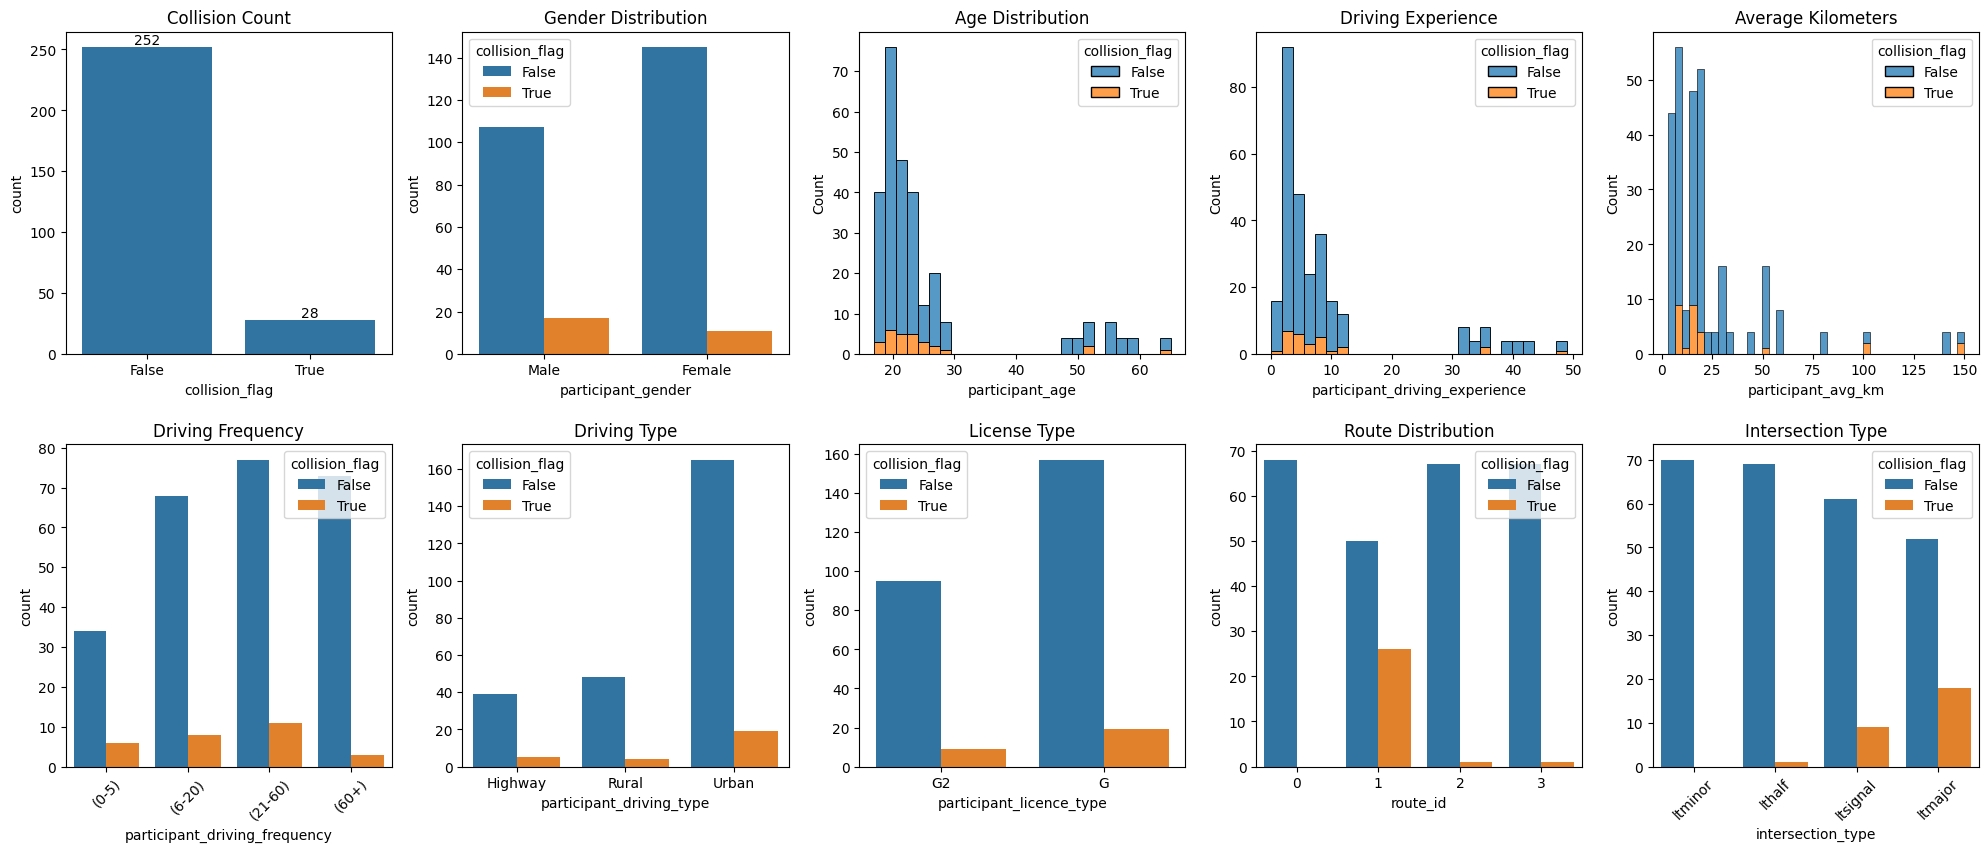

In [5]:
plt.figure(figsize=(20, 12))

plt.subplot(3, 5, 1)
ax = sns.countplot(data=encounter_meta, x='collision_flag')
ax.bar_label(ax.containers[0])
ax.set_title('Collision Count')

plt.subplot(3, 5, 2)
ax = sns.countplot(encounter_meta, x='participant_gender', hue='collision_flag',order=['Male','Female'])
ax.set_title('Gender Distribution')

plt.subplot(3, 5, 3)
ax = sns.histplot(encounter_meta, x='participant_age', hue='collision_flag', multiple='stack')
ax.set_title('Age Distribution')

plt.subplot(3, 5, 4)
ax = sns.histplot(encounter_meta, x='participant_driving_experience', hue='collision_flag', multiple='stack')
ax.set_title('Driving Experience')

plt.subplot(3, 5, 5)
ax = sns.histplot(encounter_meta, x='participant_avg_km', hue='collision_flag', multiple='stack')
ax.set_title('Average Kilometers')

plt.subplot(3, 5, 6)
ax = sns.countplot(encounter_meta, x='participant_driving_frequency', hue='collision_flag', order=['(0-5)','(6-20)','(21-60)','(60+)'])
ax.set_title('Driving Frequency')
plt.xticks(rotation=45)

plt.subplot(3, 5, 7)
ax = sns.countplot(encounter_meta, x='participant_driving_type', hue='collision_flag', order=['Highway','Rural','Urban'])
ax.set_title('Driving Type')

plt.subplot(3, 5, 8)
ax = sns.countplot(encounter_meta, x='participant_licence_type', hue='collision_flag',  order=['G2','G'])
ax.set_title('License Type')

plt.subplot(3, 5, 9)
ax = sns.countplot(encounter_meta, x='route_id', hue='collision_flag')
ax.set_title('Route Distribution')

plt.subplot(3, 5, 10)
ax = sns.countplot(encounter_meta, x='intersection_type', hue='collision_flag',order=['ltminor','lthalf','ltsignal','ltmajor'])
ax.set_title('Intersection Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Data Windowing
Apply sliding window technique to the data using a window size of window_length defined below

In [6]:
window_length = 20 # set the window length to pull from the encounters

for e_idx,encounter in enumerate(tqdm(encounter_list, desc='Processing encounters',colour='Yellow')):
    encounter_data = encounter['encounter_data']
    if 'Unnamed: 0' in encounter_data.columns:
        encounter_data.drop(columns=['Unnamed: 0'],inplace=True)

    # separate the time_to_collision from the encounter and remove the first window set to retain only the values that will be at the end of the flattened window
    time_to_collision_column = encounter_data['time_to_collision'].copy()
    time_to_collision_column = time_to_collision_column[window_length-1:].reset_index(drop=True)
    encounter_data = encounter_data.drop(columns=['time_to_collision']).reset_index(drop=True)

    column_names = encounter_data.columns # single window column names
    window_column_names = [] # updated list of column names with window stamps appended
    for w in range(window_length):
        for cn in column_names:
            new_column_name = cn + f'_{w}'
            window_column_names.append(new_column_name)

    encounter_windows = [] # list of encounter windows flattened

    for w in range(len(encounter_data) - window_length + 1):
        window_df = encounter_data[w:(w+window_length)] # obtain the window from the dataset
        window_record = window_df.values.flatten() # flatten the current window
        # append the flattened window to the list of encounters
        encounter_windows.append(window_record)
    # convert list of windows to a pandas dataframe
    encounter_windows_df = pd.DataFrame(encounter_windows,columns=window_column_names)
    # merge the encounter with the spliced time_to_collision to retain only the last record time_to_collision values
    encounter_windows_df = pd.concat([encounter_windows_df,pd.DataFrame(time_to_collision_column,columns=['time_to_collision'])],axis=1)
    encounter_windows_df['collision_flag'] = encounter['encounter_meta']['collision_flag'] # also add collision flag as a column
    encounter_list[e_idx]['encounter_data'] = encounter_windows_df # replace current encounter with windowed data

Processing encounters: 100%|██████████| 280/280 [00:18<00:00, 14.86it/s]


In [7]:
encounter_id_list = [encounter['encounter_meta']['encounter_id'] for encounter in encounter_list]
encounter_cflag_list = [encounter['encounter_meta']['collision_flag'] for encounter in encounter_list]

os.makedirs('results/nested_cv_results', exist_ok=True)

os.makedirs('results/nested_cv_results', exist_ok=True)
i = 0
while os.path.exists(f'results/nested_cv_results/nested_cv_results_{i}.csv'): i += 1
results_file = f'results/nested_cv_results/nested_cv_results_{i}.csv'
pd.DataFrame(columns=['model', 'best_params', 'accuracy', 'precision', 'recall', 'f1', 'grid_search_time']).to_csv(results_file, index=False)

outer_results = []

outer_folds = 5
inner_folds = 5
outer_fold_count = 0

verbose_value = 0
# use stratified k-fold split to split evenly across the encounters and balance collision counts
outer_cv = StratifiedGroupKFold(n_splits=outer_folds)
outer_cv_iterator = outer_cv.split(encounter_list,encounter_cflag_list,groups=encounter_id_list)

# set up the outer train/test fold loop
for outer_train_idx,outer_test_idx in outer_cv_iterator:
    outer_fold_count += 1
    print(f'entered into test fold iteration {outer_fold_count}')

    train_encounters = [encounter_list[i] for i in outer_train_idx]
    test_encounters = [encounter_list[i] for i in outer_test_idx]

    train_df = pd.concat([encounter['encounter_data'] for encounter in train_encounters],ignore_index=True)
    test_df = pd.concat([encounter['encounter_data'] for encounter in test_encounters],ignore_index=True)

    feature_columns = [col for col in train_df.columns if col not in ['collision_flag','time_to_collision']]
    #  split into the train/test components based on the stratified k fold split earlier and separate the labels from the features
    # also pull classification labels and regrression labels out
    X_train = train_df[feature_columns]
    y_train_class = train_df['collision_flag']
    y_train_regress = train_df['time_to_collision']

    X_test = test_df[feature_columns]
    y_test_class = test_df['collision_flag']
    y_test_regress = test_df['time_to_collision']

    outer_scaler = StandardScaler()
    X_train_scaled = outer_scaler.fit_transform(X_train)
    X_test_scaled = outer_scaler.transform(X_test)

    inner_cv = StratifiedKFold(n_splits=inner_folds)
    # set up models to test on the inner cv loop for the given test fold
    models = {
        'random_forest': {
            'model': RandomForestClassifier(n_jobs=-1, n_estimators=100,verbose=verbose_value),  # Parallelize within the model
            'params': {
                'clf__max_depth': [None]
            }
        },
        'sgd_classifier': {
            'model': SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, early_stopping=True, n_jobs=-1,verbose=verbose_value),
            'params': {
                'clf__alpha': [0.0001, 0.001],
                'clf__penalty': ['l2']
            }
        },
        'xgboost': {
            'model': XGBClassifier(n_jobs=-1, 
                                tree_method='gpu_hist',  # Enable GPU acceleration
                                gpu_id=0,               # Use first GPU
                                use_label_encoder=False,
                                eval_metric='logloss'),
            'params': {
                'clf__n_estimators': [100],
                'clf__learning_rate': [0.1],
                'clf__max_depth': [6]
            }
        },
        # 'logistic_regression': {
        #     'model': LogisticRegression(solver='saga', max_iter=1000, tol=1e-4, n_jobs=-1, verbose=verbose_value),
        #     'params': {
        #         'clf__C': [10],
        #         'clf__penalty': ['l1', 'l2']
        #     }
        # },
        # 'svm': {
        #     'model': SVC(kernel='linear', cache_size=2000, tol=1e-3),  # Increased cache size and looser tolerance
        #     'params': {
        #         'clf__C': [1],
        #     }
        # }
    }

    # run nested cv for each model in list above
    for model_name, model_params in models.items():
        print(f'creating pipeline for {model_name} - {model_params['params']}')
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model_params['model'])
        ])
        print(f'performing grid search')
        start_time = time.time()

        grid = GridSearchCV(pipe, model_params['params'],cv=inner_cv,scoring='accuracy',verbose=verbose_value,n_jobs=-1)
        grid.fit(X_train, y_train_class)

        end_time = time.time()
        grid_search_time = end_time - start_time

        best_model = grid.best_estimator_
        print(f'finished grid search - found best model: {best_model} in {grid_search_time}')
        y_pred = best_model.named_steps['clf'].predict(X_test_scaled)
        print(f'finished prediction using best model - getting results')
        model_scoring_report = classification_report(y_test_class, y_pred, output_dict=True)
        model_accuracy = accuracy_score(y_test_class,y_pred)
        model_precision = precision_score(y_test_class,y_pred) 
        model_recall = recall_score(y_test_class,y_pred)
        model_f1 = f1_score(y_test_class,y_pred)
        result_entry = {
            'model': model_name,
            'best_params': str(grid.best_params_),
            'accuracy': model_accuracy,
            'precision': model_precision,
            'recall': model_recall,
            'f1': model_f1,
            'grid_search_time' : grid_search_time
        }
        print(f'results from predictions using {best_model}: {model_scoring_report}')
        # append to csv
        pd.DataFrame([result_entry]).to_csv(results_file, mode='a', header=False, index=False)

        # add to outer results in memory
        outer_results.append(result_entry)


entered into test fold iteration 1
creating pipeline for random_forest - {'clf__max_depth': [None]}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(n_jobs=-1))]) in 67.70032167434692
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(n_jobs=-1))]): {'False': {'precision': 0.9970472782853371, 'recall': 0.9807620023919358, 'f1-score': 0.9888375938813477, 'support': 29265.0}, 'True': {'precision': 0.831133773245351, 'recall': 0.9702380952380952, 'f1-score': 0.8953150242326333, 'support': 2856.0}, 'accuracy': 0.9798262818716728, 'macro avg': {'precision': 0.914090525765344, 'recall': 0.9755000488150155, 'f1-score': 0.9420763090569906, 'support': 32121.0}, 'weighted avg': {'precision': 0.982295278957975, 'recall': 0.9798262818716728, 'f1-score': 0.9805221473

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:43:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:43:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:43:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrai

finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, gpu_id=0, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_wei

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:2676: UserWarning: [10:43:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:729: UserWarning: [10:43:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only b

results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, gpu_id=0, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, 

...

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:2676: UserWarning: [10:49:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


creating pipeline for random_forest - {'clf__max_depth': [None]}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(n_jobs=-1))]) in 49.05307412147522
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(n_jobs=-1))]): {'False': {'precision': 0.978760802695181, 'recall': 0.9308999721370855, 'f1-score': 0.9542306319171724, 'support': 28712.0}, 'True': {'precision': 0.5900826446280992, 'recall': 0.8311990686845169, 'f1-score': 0.6901884968583857, 'support': 3436.0}, 'accuracy': 0.9202438720915764, 'macro avg': {'precision': 0.7844217236616401, 'recall': 0.8810495204108012, 'f1-score': 0.822209564387779, 'support': 32148.0}, 'weighted avg': {'precision': 0.937218618076589, 'recall': 0.9202438720915764, 'f1-score': 0.9260096298000269, 'support': 32148.0}}
creati

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:51:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:51:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, gpu_id=0, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_wei

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:2676: UserWarning: [10:51:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


In [8]:
results_df = pd.DataFrame(outer_results)
model_averages = results_df.groupby('model').mean(numeric_only=True)
print(model_averages)

                accuracy  precision    recall        f1  grid_search_time
model                                                                    
random_forest   0.971443   0.879546  0.873023  0.863081         59.849393
sgd_classifier  0.884533   0.425135  0.361425  0.382503         37.149156
xgboost         0.969800   0.864243  0.877092  0.860418         25.444817


In [10]:
encounter_id_list = [encounter['encounter_meta']['encounter_id'] for encounter in encounter_list]
encounter_cflag_list = [encounter['encounter_meta']['collision_flag'] for encounter in encounter_list]

os.makedirs('results/nested_cv_results', exist_ok=True)

os.makedirs('results/nested_cv_results', exist_ok=True)
i = 0
while os.path.exists(f'results/nested_cv_results/nested_cv_results_{i}.csv'): i += 1
results_file = f'results/nested_cv_results/nested_cv_results_{i}.csv'
pd.DataFrame(columns=['model', 'best_params', 'accuracy', 'precision', 'recall', 'f1', 'grid_search_time']).to_csv(results_file, index=False)

outer_results = []

outer_folds = 5
inner_folds = 5
outer_fold_count = 0

verbose_value = 0
# use stratified k-fold split to split evenly across the encounters and balance collision counts
outer_cv = StratifiedGroupKFold(n_splits=outer_folds)
outer_cv_iterator = outer_cv.split(encounter_list,encounter_cflag_list,groups=encounter_id_list)

# set up the outer train/test fold loop
for outer_train_idx,outer_test_idx in outer_cv_iterator:
    outer_fold_count += 1
    print(f'entered into test fold iteration {outer_fold_count}')

    train_encounters = [encounter_list[i] for i in outer_train_idx]
    test_encounters = [encounter_list[i] for i in outer_test_idx]

    train_df = pd.concat([encounter['encounter_data'] for encounter in train_encounters],ignore_index=True)
    test_df = pd.concat([encounter['encounter_data'] for encounter in test_encounters],ignore_index=True)

    feature_columns = [col for col in train_df.columns if col not in ['collision_flag','time_to_collision']]
    feature_columns = [c for c in feature_columns if all(k not in c for k in ['position', 'ego_to_haz_dist', 'Timestamp'])] # remove potential discrepancy features
    
    #  split into the train/test components based on the stratified k fold split earlier and separate the labels from the features
    # also pull classification labels and regrression labels out
    X_train = train_df[feature_columns]
    y_train_class = train_df['collision_flag']
    y_train_regress = train_df['time_to_collision']

    X_test = test_df[feature_columns]
    y_test_class = test_df['collision_flag']
    y_test_regress = test_df['time_to_collision']

    outer_scaler = StandardScaler()
    X_train_scaled = outer_scaler.fit_transform(X_train)
    X_test_scaled = outer_scaler.transform(X_test)

    inner_cv = StratifiedKFold(n_splits=inner_folds)
    # set up models to test on the inner cv loop for the given test fold
    models = {
        'random_forest': {
            'model': RandomForestClassifier(n_jobs=-1,verbose=verbose_value),  # Parallelize within the model
            'params': {
                'clf__criterion': ['gini','log_loss','entropy'],
                'clf__max_depth': [None,5,10,15,20],
                'clf__n_estimators': [5,10,50,100,250]
            }
        },
        'sgd_classifier': {
            'model': SGDClassifier(max_iter=1000, tol=1e-3, early_stopping=True, n_jobs=-1,verbose=verbose_value),
            'params': {
                'clf__loss': ['log_loss','hinge'],
                'clf__alpha': [0.0001, 0.001,0.01,0.1,1,10,100],
                'clf__penalty': ['l1','l2']
            }
        },
        # 'xgboost': {
        #     'model': XGBClassifier(n_jobs=-1, 
        #                         tree_method='gpu_hist',  # Enable GPU acceleration
        #                         gpu_id=0,               # Use first GPU
        #                         use_label_encoder=False,
        #                         eval_metric='logloss'),
        #     'params': {
        #         'clf__n_estimators': [10,25,50,100],
        #         'clf__learning_rate': [0.1,0.01,0.001,0.0001],
        #         'clf__max_depth': [5,10,50,100,250]
        #     }
        # },
        # 'logistic_regression': {
        #     'model': LogisticRegression(solver='saga', max_iter=1000, tol=1e-4, n_jobs=-1, verbose=verbose_value),
        #     'params': {
        #         'clf__C': [10],
        #         'clf__penalty': ['l1', 'l2']
        #     }
        # },
        # 'svm': {
        #     'model': SVC(kernel='linear', cache_size=2000, tol=1e-3),  # Increased cache size and looser tolerance
        #     'params': {
        #         'clf__C': [1],
        #     }
        # }
    }

    # run nested cv for each model in list above
    for model_name, model_params in models.items():
        print(f'creating pipeline for {model_name} - {model_params['params']}')
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model_params['model'])
        ])
        print(f'performing grid search')
        start_time = time.time()

        grid = GridSearchCV(pipe, model_params['params'],cv=inner_cv,scoring='accuracy',verbose=verbose_value,n_jobs=-1)
        grid.fit(X_train, y_train_class)

        end_time = time.time()
        grid_search_time = end_time - start_time

        best_model = grid.best_estimator_
        print(f'finished grid search - found best model: {best_model} in {grid_search_time}')
        y_pred = best_model.named_steps['clf'].predict(X_test_scaled)
        print(f'finished prediction using best model - getting results')
        model_scoring_report = classification_report(y_test_class, y_pred, output_dict=True)
        model_accuracy = accuracy_score(y_test_class,y_pred)
        model_precision = precision_score(y_test_class,y_pred) 
        model_recall = recall_score(y_test_class,y_pred)
        model_f1 = f1_score(y_test_class,y_pred)
        result_entry = {
            'model': model_name,
            'best_params': str(grid.best_params_),
            'accuracy': model_accuracy,
            'precision': model_precision,
            'recall': model_recall,
            'f1': model_f1,
            'grid_search_time' : grid_search_time
        }
        print(f'results from predictions using {best_model}: {model_scoring_report}')
        # append to csv
        pd.DataFrame([result_entry]).to_csv(results_file, mode='a', header=False, index=False)

        # add to outer results in memory
        outer_results.append(result_entry)


entered into test fold iteration 1
creating pipeline for random_forest - {'clf__criterion': ['gini', 'log_loss', 'entropy'], 'clf__max_depth': [None, 5, 10, 15, 20], 'clf__n_estimators': [5, 10, 50, 100, 250]}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(criterion='entropy', max_depth=20,
                                        n_estimators=10, n_jobs=-1))]) in 2847.7986023426056
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(criterion='entropy', max_depth=20,
                                        n_estimators=10, n_jobs=-1))]): {'False': {'precision': 0.9560413080895008, 'recall': 0.9490175978130873, 'f1-score': 0.9525165051873445, 'support': 29265.0}, 'True': {'precision': 0.5141647671768154, 'recall': 0.5528

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

creating pipeline for random_forest - {'clf__criterion': ['gini', 'log_loss', 'entropy'], 'clf__max_depth': [None, 5, 10, 15, 20], 'clf__n_estimators': [5, 10, 50, 100, 250]}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(criterion='log_loss', max_depth=20,
                                        n_estimators=50, n_jobs=-1))]) in 2836.2883040905
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(criterion='log_loss', max_depth=20,
                                        n_estimators=50, n_jobs=-1))]): {'False': {'precision': 0.9382202523013979, 'recall': 0.9567817530683912, 'f1-score': 0.9474100979497685, 'support': 28761.0}, 'True': {'precision': 0.5697473174108688, 'recall': 0.4759976865240023, 'f1-score': 0.51867023

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

creating pipeline for random_forest - {'clf__criterion': ['gini', 'log_loss', 'entropy'], 'clf__max_depth': [None, 5, 10, 15, 20], 'clf__n_estimators': [5, 10, 50, 100, 250]}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(n_jobs=-1))]) in 2857.041559457779
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(n_jobs=-1))]): {'False': {'precision': 0.9671564692331855, 'recall': 0.9642621011239865, 'f1-score': 0.9657071164703422, 'support': 28737.0}, 'True': {'precision': 0.7113546936481169, 'recall': 0.7289746543778802, 'f1-score': 0.7200568990042674, 'support': 3472.0}, 'accuracy': 0.9388990654785929, 'macro avg': {'precision': 0.8392555814406513, 'recall': 0.8466183777509333, 'f1-score': 0.8428820077373048, 'support': 32209.0}, 'weighted avg': {'precisio

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

creating pipeline for random_forest - {'clf__criterion': ['gini', 'log_loss', 'entropy'], 'clf__max_depth': [None, 5, 10, 15, 20], 'clf__n_estimators': [5, 10, 50, 100, 250]}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(criterion='log_loss', n_estimators=250,
                                        n_jobs=-1))]) in 2342.4918649196625
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(criterion='log_loss', n_estimators=250,
                                        n_jobs=-1))]): {'False': {'precision': 0.9270472307169555, 'recall': 0.9502298690443021, 'f1-score': 0.9384954077947095, 'support': 28712.0}, 'True': {'precision': 0.4742457689477557, 'recall': 0.37514551804423746, 'f1-score': 0.4189145271368216, 'support': 3

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [11]:
results_df = pd.DataFrame(outer_results)
model_averages = results_df.groupby('model').mean(numeric_only=True)
print(model_averages)

                accuracy  precision    recall        f1  grid_search_time
model                                                                    
random_forest   0.915704   0.582763  0.533120  0.554723       2672.378974
sgd_classifier  0.891312   0.013183  0.007353  0.009440        153.882408


In [17]:
encounter_id_list = [encounter['encounter_meta']['encounter_id'] for encounter in encounter_list]
encounter_cflag_list = [encounter['encounter_meta']['collision_flag'] for encounter in encounter_list]

os.makedirs('results/nested_cv_results', exist_ok=True)

os.makedirs('results/nested_cv_results', exist_ok=True)
i = 0
while os.path.exists(f'results/nested_cv_results/nested_cv_results_regression_{i}.csv'): i += 1
results_file = f'results/nested_cv_results/nested_cv_results_regression_{i}.csv'
pd.DataFrame(columns=['model', 'best_params', 'mse', 'r2','grid_search_time']).to_csv(results_file, index=False)

outer_results_regress = []

outer_folds = 5
inner_folds = 5
outer_fold_count = 0

verbose_value = 0
# use stratified k-fold split to split evenly across the encounters and balance collision counts
outer_cv = StratifiedGroupKFold(n_splits=outer_folds)
outer_cv_iterator = outer_cv.split(encounter_list,encounter_cflag_list,groups=encounter_id_list)

# set up the outer train/test fold loop
for outer_train_idx,outer_test_idx in outer_cv_iterator:
    outer_fold_count += 1
    print(f'entered into test fold iteration {outer_fold_count}')

    train_encounters = [encounter_list[i] for i in outer_train_idx]
    test_encounters = [encounter_list[i] for i in outer_test_idx]

    train_df = pd.concat([encounter['encounter_data'] for encounter in train_encounters],ignore_index=True)
    test_df = pd.concat([encounter['encounter_data'] for encounter in test_encounters],ignore_index=True)

    feature_columns = [col for col in train_df.columns if col not in ['collision_flag','time_to_collision']]
    feature_columns = [c for c in feature_columns if all(k not in c for k in ['position', 'ego_to_haz_dist', 'Timestamp'])] # remove potential discrepancy features
    
    #  split into the train/test components based on the stratified k fold split earlier and separate the labels from the features
    # also pull classification labels and regrression labels out
    X_train = train_df[feature_columns]
    y_train_class = train_df['collision_flag']
    y_train_regress = train_df['time_to_collision']

    X_test = test_df[feature_columns]
    y_test_class = test_df['collision_flag']
    y_test_regress = test_df['time_to_collision']

    outer_scaler = StandardScaler()
    X_train_scaled = outer_scaler.fit_transform(X_train)
    X_test_scaled = outer_scaler.transform(X_test)

    inner_cv = KFold(n_splits=inner_folds, shuffle=True, random_state=42)
    # set up models to test on the inner cv loop for the given test fold
    models = {
        'random_forest_regressor': {
            'model': RandomForestRegressor(n_jobs=-1, verbose=verbose_value),
            'params': {
                'clf__max_depth': [None],
                'clf__n_estimators': [100]
            }
        },
        'sgd_regressor': {
            'model': SGDRegressor(max_iter=1000, tol=1e-3, early_stopping=True, verbose=verbose_value),
            'params': {
                'clf__alpha': [1],
                'clf__penalty': ['l1', 'l2']
            }
        },
    }

    # run nested cv for each model in list above
    for model_name, model_params in models.items():
        print(f'creating pipeline for {model_name} - {model_params['params']}')
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model_params['model'])
        ])
        print(f'performing grid search')
        start_time = time.time()

        grid = GridSearchCV(pipe, model_params['params'], cv=inner_cv,scoring='neg_mean_squared_error', verbose=verbose_value, n_jobs=-1)
        grid.fit(X_train, y_train_regress)

        end_time = time.time()
        grid_search_time = end_time - start_time

        best_model = grid.best_estimator_
        print(f'finished grid search - found best model: {best_model} in {grid_search_time}')
        y_pred = best_model.predict(X_test_scaled)
        print(f'finished prediction using best model - getting results')
        model_mse = mean_squared_error(y_test_regress, y_pred)
        model_r2 = r2_score(y_test_regress, y_pred)
        result_entry = {
            'model': model_name,
            'best_params': str(grid.best_params_),
            'mse': model_mse,
            'r2': model_r2,
            'grid_search_time': grid_search_time
        }
        print(f'results from predictions using {best_model}: {result_entry}')
        # append to csv
        pd.DataFrame([result_entry]).to_csv(results_file, mode='a', header=False, index=False)

        # add to outer results in memory
        outer_results_regress.append(result_entry)


entered into test fold iteration 1
creating pipeline for random_forest_regressor - {'clf__max_depth': [None], 'clf__n_estimators': [100]}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestRegressor(n_jobs=-1))]) in 1875.2996273040771
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestRegressor(n_jobs=-1))]): {'False': {'precision': 0.8931193231305213, 'recall': 1.0, 'f1-score': 0.9435425566874794, 'support': 28712.0}, 'True': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3436.0}, 'accuracy': 0.8931193231305213, 'macro avg': {'precision': 0.44655966156526067, 'recall': 0.5, 'f1-score': 0.4717712783437397, 'support': 32148.0}, 'weighted avg': {'precision': 0.7976621253491206, 'recall': 0.8931193231305213, 'f1-score': 0.8426960895735631, 'support': 32148.0}}


c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


creating pipeline for sgd_regressor - {'clf__alpha': [1], 'clf__penalty': ['l1', 'l2']}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', SGDRegressor(alpha=1, early_stopping=True))]) in 24.113253593444824
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', SGDRegressor(alpha=1, early_stopping=True))]): {'False': {'precision': 0.8931193231305213, 'recall': 1.0, 'f1-score': 0.9435425566874794, 'support': 28712.0}, 'True': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3436.0}, 'accuracy': 0.8931193231305213, 'macro avg': {'precision': 0.44655966156526067, 'recall': 0.5, 'f1-score': 0.4717712783437397, 'support': 32148.0}, 'weighted avg': {'precision': 0.7976621253491206, 'recall': 0.8931193231305213, 'f1-score': 0.8426960895735631, 'support': 32148.0}}
entered into test fold iteration 2


c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


creating pipeline for random_forest_regressor - {'clf__max_depth': [None], 'clf__n_estimators': [100]}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestRegressor(n_jobs=-1))]) in 1518.9791548252106
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestRegressor(n_jobs=-1))]): {'False': {'precision': 0.8931193231305213, 'recall': 1.0, 'f1-score': 0.9435425566874794, 'support': 28712.0}, 'True': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3436.0}, 'accuracy': 0.8931193231305213, 'macro avg': {'precision': 0.44655966156526067, 'recall': 0.5, 'f1-score': 0.4717712783437397, 'support': 32148.0}, 'weighted avg': {'precision': 0.7976621253491206, 'recall': 0.8931193231305213, 'f1-score': 0.8426960895735631, 'support': 32148.0}}
creating pipeline for sgd_regressor - {'

...

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


creating pipeline for random_forest_regressor - {'clf__max_depth': [None], 'clf__n_estimators': [100]}
performing grid search
finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestRegressor(n_jobs=-1))]) in 1414.7055337429047
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestRegressor(n_jobs=-1))]): {'False': {'precision': 0.8931193231305213, 'recall': 1.0, 'f1-score': 0.9435425566874794, 'support': 28712.0}, 'True': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3436.0}, 'accuracy': 0.8931193231305213, 'macro avg': {'precision': 0.44655966156526067, 'recall': 0.5, 'f1-score': 0.4717712783437397, 'support': 32148.0}, 'weighted avg': {'precision': 0.7976621253491206, 'recall': 0.8931193231305213, 'f1-score': 0.8426960895735631, 'support': 32148.0}}
creating pipeline for sgd_regressor - {'

c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


finished grid search - found best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', SGDRegressor(alpha=1, early_stopping=True))]) in 24.67670249938965
finished prediction using best model - getting results
results from predictions using Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', SGDRegressor(alpha=1, early_stopping=True))]): {'False': {'precision': 0.8931193231305213, 'recall': 1.0, 'f1-score': 0.9435425566874794, 'support': 28712.0}, 'True': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3436.0}, 'accuracy': 0.8931193231305213, 'macro avg': {'precision': 0.44655966156526067, 'recall': 0.5, 'f1-score': 0.4717712783437397, 'support': 32148.0}, 'weighted avg': {'precision': 0.7976621253491206, 'recall': 0.8931193231305213, 'f1-score': 0.8426960895735631, 'support': 32148.0}}


c:\Users\01eco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
regression_results_df = pd.DataFrame(outer_results_regress)
regression_model_averages = regression_results_df.groupby('model').mean(numeric_only=True)
print(regression_model_averages)

                                  mse            r2  grid_search_time
model                                                                
random_forest_regressor  9.552982e+04 -6.830606e-02       1679.162384
sgd_regressor            2.445844e+21 -2.582827e+16         27.968688
